# Step 7 — Project the 11 ST clusters onto chemotherapy cohorts

Applies the Seurat anchor-based transfer of TCGA's 11 ST-cluster labels onto the
chemotherapy-treated PBCP slides (19 slides — the `treatment == "chemo"` subset
of the 37-slide PBCP cohort). The cohort uses its own tuned anchor preset,
distinct from the trastuzumab parameter set (see
[`../lib/transfer_TCGA_to_external.R`](../lib/transfer_TCGA_to_external.R) ::
`TRANSFER_PRESETS$PBCP_Chemo`).

Currently the chemotherapy "cohorts" group has only PBCP; the notebook is set
up so additional chemotherapy cohorts (e.g., TransNEO-Chemo, IMPRESS-Chemo)
can be added later as more rows in the same heatmap section.

**Inputs (committed under `clustering/data/`)**
- `pbcp_query.qs` — PBCP per-domain Seurat object (full 289 domains).

**Outputs (committed under `clustering/data/`)**
- `pbcp_chemo_per_domain.csv` / `pbcp_chemo_cluster_props.csv` (chemo subset).

## Setup

In [1]:
import sys, subprocess
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from clustering_helpers import HEATMAP_ROW_ORDER

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

REFERENCE_QS = "/vf/users/Ruppin_ST/scr/new_tras_clusters/tcga_target_seurat_best_genes.qs"

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## What are `target` and `query`?

- **`target`** — same TCGA reference Seurat object used across all transfer notebooks
  (notebooks 04–07).
- **`query`** — `pbcp_query.qs`, the PBCP per-domain Seurat object. PBCP holds both
  trastuzumab- and chemo-treated patients in one object; the chemo subset is selected
  by `treatment == "chemo"` after the transfer.

In [2]:
def inspect_qs(qs_path, label):
    res = subprocess.run(
        ["bash", "-c",
         f"source /etc/profile.d/modules.sh 2>/dev/null; "
         f"module load R/4.3.2 2>/dev/null; "
         f"Rscript ../lib/inspect_seurat.R {qs_path} '{label}'"],
        capture_output=True, text=True,
    )
    print("\n".join(l for l in res.stdout.splitlines() if "lscratch" not in l))

# inspect_qs(REFERENCE_QS, "TCGA reference (target)")  # uncomment to run
# inspect_qs("../data/pbcp_query.qs", "PBCP")

## Stage 1 — Project labels

PBCP chemo preset. The committed CSV has the chemo subset only.

In [3]:
# Uncomment to re-run (needs R + Seurat + access to the upstream TCGA .qs):
# subprocess.run(["bash", "-c",
#     f"source /etc/profile.d/modules.sh; module load R/4.3.2; "
#     f"Rscript ../lib/transfer_TCGA_to_external.R "
#     f"{REFERENCE_QS} ../data/pbcp_query.qs ../data/pbcp_chemo_cluster_props.csv PBCP_Chemo"],
#     check=True)
# Note: the PBCP_Chemo preset is applied to the FULL PBCP Seurat object (289 domains).
# The chemo subset is selected downstream by `treatment == "chemo"`.

props = pd.read_csv("../data/pbcp_chemo_cluster_props.csv", index_col=0)
print("PBCP chemo:", props.shape, "patients")

PBCP chemo: (19, 11) patients


## Stage 2 — Heatmap of cluster proportions per cohort (z-score)

In [4]:
def _zscore_rows(M):
    mu = M.mean(axis=1, keepdims=True); s = M.std(axis=1, keepdims=True)
    s[s == 0] = 1
    return (M - mu) / s

def draw_cohort_heatmap(props_csv, title, max_cols=None):
    df = pd.read_csv(props_csv, index_col=0)
    df = df.rename(columns={f"Cluster_{i}": f"Cluster {i}" for i in range(1, 12)})
    # Order patients by Ward dendrogram across all 11 clusters
    from scipy.cluster.hierarchy import linkage, leaves_list
    sub_mat = df[HEATMAP_ROW_ORDER].values
    if len(df) > 1:
        order = leaves_list(linkage(sub_mat, method="ward"))
    else:
        order = np.arange(len(df))
    raw = df.iloc[order][HEATMAP_ROW_ORDER].T.values
    heat = _zscore_rows(raw)

    from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
    v_lo, v_mid, v_hi = float(heat.min()), 2.85, float(heat.max())
    cmap = LinearSegmentedColormap.from_list(
        "viridis3", plt.get_cmap("viridis")(np.linspace(0, 1, 3)), N=256
    )
    norm = TwoSlopeNorm(vmin=v_lo, vcenter=min(v_mid, v_hi - 1e-6), vmax=v_hi)

    fig = plt.figure(figsize=(max(4.2, 0.18 * heat.shape[1] + 2), 3.0))
    gs  = gridspec.GridSpec(1, 2, figure=fig,
                             width_ratios=[60, 1], hspace=0.05, wspace=0.02)
    ax_h = fig.add_subplot(gs[0, 0])
    im = ax_h.imshow(heat, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
    ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
    ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
    ax_h.set_xticks([]); ax_h.tick_params(left=False)
    ax_h.set_title(title, fontsize=8)
    ax_cb = fig.add_subplot(gs[0, 1])
    plt.colorbar(im, cax=ax_cb).set_label("Z-score", fontsize=7)
    ax_cb.tick_params(labelsize=6)
    plt.show()

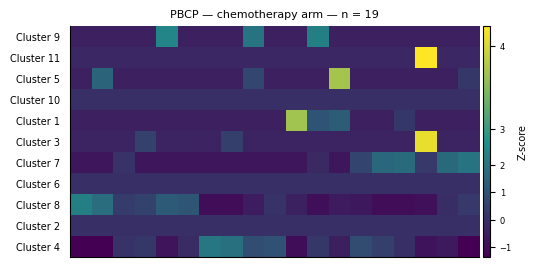

In [5]:
draw_cohort_heatmap("../data/pbcp_chemo_cluster_props.csv",
                    "PBCP — chemotherapy arm — n = " + str(len(props)))